In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem


In [2]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

### Load and combine scRNA and ATAC seq data

In [3]:
rna_path = '/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/stream_input_filtered_cells_v7.h5ad'
atac_path = '/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/adata_aggregated_peak.leiden.h5ad'

In [4]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

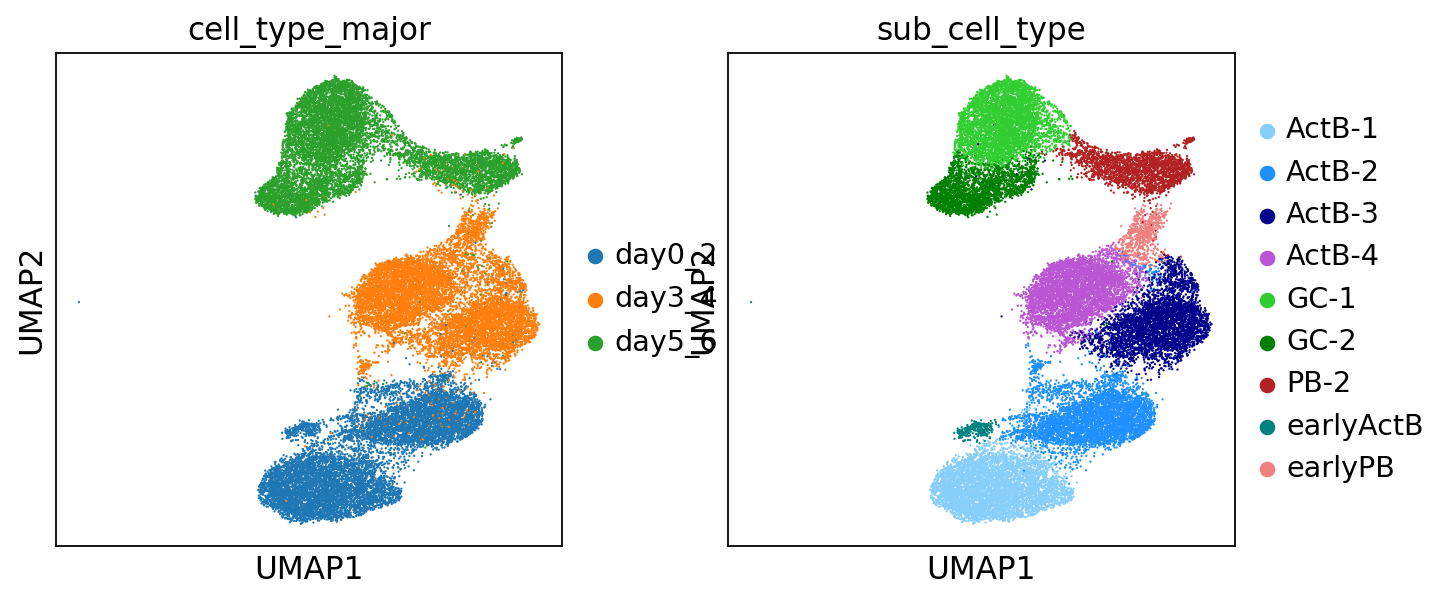

In [6]:
sc.pl.umap(rna_adata, color=['cell_type_major', 'sub_cell_type'])

In [7]:
rna_adata.obs['cell_type_major']

AAACAGCCAAGCCACT-3    day5_6
AAACAGCCAAGGTGCA-1    day0_2
AAACAGCCAAGTTATC-1    day0_2
AAACAGCCAATAGCCC-1    day0_2
AAACAGCCAGTTAGCC-1    day0_2
                       ...  
TTTGTTGGTTTACGTC-1    day0_2
TTTGTTGGTTTAGTCC-1    day0_2
TTTGTTGGTTTATGGG-2    day3_4
TTTGTTGGTTTCCTCC-3    day5_6
TTTGTTGGTTTGAGGC-2    day3_4
Name: cell_type_major, Length: 28494, dtype: category
Categories (3, str): ['day0_2', 'day3_4', 'day5_6']

In [8]:
atac_adata = sc.read_h5ad(atac_path)
atac_adata

AnnData object with n_obs × n_vars = 32418 × 191255
    obs: 'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'topic_dendogram'
    obsm: 'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
    varm: 'topic_feature_activations', 'topic_feature_compositions'
    layers: 'counts'

In [9]:
atac_adata.var

,gene_ids,feature_types,genome
chr1:9809-10677,chr1:9809-10677,Peaks,GRCh38
chr1:28988-29868,chr1:28988-29868,Peaks,GRCh38
chr1:180722-180992,chr1:180722-180992,Peaks,GRCh38
chr1:181093-181802,chr1:181093-181802,Peaks,GRCh38
chr1:267555-268452,chr1:267555-268452,Peaks,GRCh38
...,...,...,...
KI270713.1:29710-30533,KI270713.1:29710-30533,Peaks,GRCh38
KI270713.1:31281-32210,KI270713.1:31281-32210,Peaks,GRCh38
KI270713.1:32672-33147,KI270713.1:32672-33147,Peaks,GRCh38
KI270713.1:33255-33832,KI270713.1:33255-33832,Peaks,GRCh38


In [10]:
# check shared cells
shared = rna_adata.obs_names.intersection(atac_adata.obs_names)
print("shared cells:", len(shared))

shared cells: 28494


In [11]:
atac_adata = atac_adata[shared].copy()

### Import mudata

In [6]:
import muon as mu

mdata = mu.read_h5mu('/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/rna_atac_multivi.h5mu')
mdata

MuData object with n_obs × n_vars = 28494 × 194273
  obs:	'_indices', '_scvi_batch', '_scvi_labels'
  var:	'gene_ids', 'feature_types', 'genome'
  uns:	'_scvi_manager_uuid', '_scvi_uuid'
  obsm:	'X_MultiVI'
  2 modalities
    rna:	28494 x 3018
      obs:	'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
      obsm:	'DM_EigenVectors', 'X_joint_umap_features', 'X_pca', 'X_topic_compositions', 'X_umap', 'X_umap_features'
      varm:	'PCs', 'topic_feature_activations', 'topic_feature_compositions'
      layers:	'MAGIC_imputed_data', 'counts'
      obsp:	'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'
    atac:	28494 x 191255
      obs:	'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome'
      uns:	'topic_dendogram'
      obsm:	'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
      varm:	'topic_feature_activations', 'topic_feature_compositions'
      layers:	'counts'

In [7]:
X = mdata.obsm["X_MultiVI"]
X.shape

(28494, 11)

In [8]:
common = rna_adata.obs_names.intersection(mdata.obs_names)
assert len(common) == rna_adata.n_obs == mdata.n_obs

rna_adata.obsm["X_MultiVI"] = mdata[rna_adata.obs_names].obsm["X_MultiVI"]


### filter cell types

In [22]:
keep_by_day = {
    "day0_2": ["ActB-1", "ActB-2", "earlyActB", "ActB-3", "ActB-4", "earlyPB"],
    "day3_4": ["ActB-1", "ActB-2", "earlyActB", "ActB-3", "ActB-4", "earlyPB", "GC-1", "GC-2", "PB-2"],
    "day5_6": ["ActB-3", "ActB-4", "earlyPB", "GC-1", "GC-2", "PB-2"],
}

day_key = "cell_type_major"
ct_key  = "sub_cell_type"

mask = rna_adata.obs.apply(lambda r: r[ct_key] in keep_by_day.get(r[day_key], []), axis=1)

adata_asym = rna_adata[mask].copy()

# cleanup
adata_asym.obs[ct_key] = adata_asym.obs[ct_key].astype("category").cat.remove_unused_categories()
adata_asym.obs[day_key] = adata_asym.obs[day_key].astype("category").cat.remove_unused_categories()

In [23]:
adata_asym

AnnData object with n_obs × n_vars = 28463 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

### preprocessing

In [24]:
# make temporal info numeric
def adapt_time(x):
    if x["cell_type_major"] == "day0_2":
        return 1.5
    if x["cell_type_major"] == "day3_4":
        return 3.5
    if x["cell_type_major"] == "day5_6":
        return 5.5
    raise ValueError

adata_asym.obs["cell_type_major"] = adata_asym.obs.apply(adapt_time, axis=1).astype("category")

In [25]:
# instantiate temporal OT problem
tp0 = TemporalProblem(adata_asym)
tp0 = tp0.prepare(time_key="cell_type_major", joint_attr="X_MultiVI")

### Compute cost matrix

In [26]:
import networkx as nx

dfs = {}
batch_column = "cell_type_major"
unique_batches = [1.5, 3.5, 5.5]

# pair wise WOT
for i in range(len(unique_batches) - 1):
    batch1 = unique_batches[i]
    batch2 = unique_batches[i + 1]

    indices = np.where(
        (adata_asym.obs[batch_column] == batch1) | (adata_asym.obs[batch_column] == batch2)
    )[0]
    adata_subset = adata_asym[indices]

    sc.pp.neighbors(adata_subset, use_rep="X_MultiVI", n_neighbors=30)
    G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
    assert nx.is_connected(G)

    # store the kNN graph as a dense pandas df and save it in a dict
    dfs[(batch1, batch2)] = pd.DataFrame(
        index=adata_subset.obs_names,
        columns=adata_subset.obs_names,
        data=adata_subset.obsp["connectivities"].todense().astype("float"),
    )

In [27]:
for (t1, t2) in [(1.5, 3.5), (3.5, 5.5)]:
    prob = tp0[t1, t2]

    expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)  # Index
    Gdf = dfs[(t1, t2)].loc[expected, expected].astype(float)

    prob.set_graph_xy(Gdf, t=100.0)


### Solve the temporal problem

In [28]:
# epsilon: entropic regularization strength
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)

INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9383, 9180)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9900, 9383)].                                  


In [ ]:
# import numpy as np
# import scipy.sparse as sp

# T_15_35 = tp0[1.5, 3.5].solution.transport_matrix
# T_35_55 = tp0[3.5, 5.5].solution.transport_matrix

# # JAX -> NumPy
# T_15_35_np = np.asarray(T_15_35)
# T_35_55_np = np.asarray(T_35_55)

# # NumPy -> sparse (CSR)
# T_15_35_csr = sp.csr_matrix(T_15_35_np)
# T_35_55_csr = sp.csr_matrix(T_35_55_np)

# sp.save_npz("/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/T_1.5_3.5.npz", T_15_35_csr)
# sp.save_npz("/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/T_3.5_5.5.npz", T_35_55_csr)

### Identify ancestor and descendants

Descendant view asks: given an early type A, where does it go?

Ancestor view asks: given a late type B, where did it come from?

In [29]:
order_celltypes = rna_adata.obs["sub_cell_type"].cat.categories.tolist()
order_celltypes

['ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'GC-1',
 'GC-2',
 'PB-2',
 'earlyActB',
 'earlyPB']

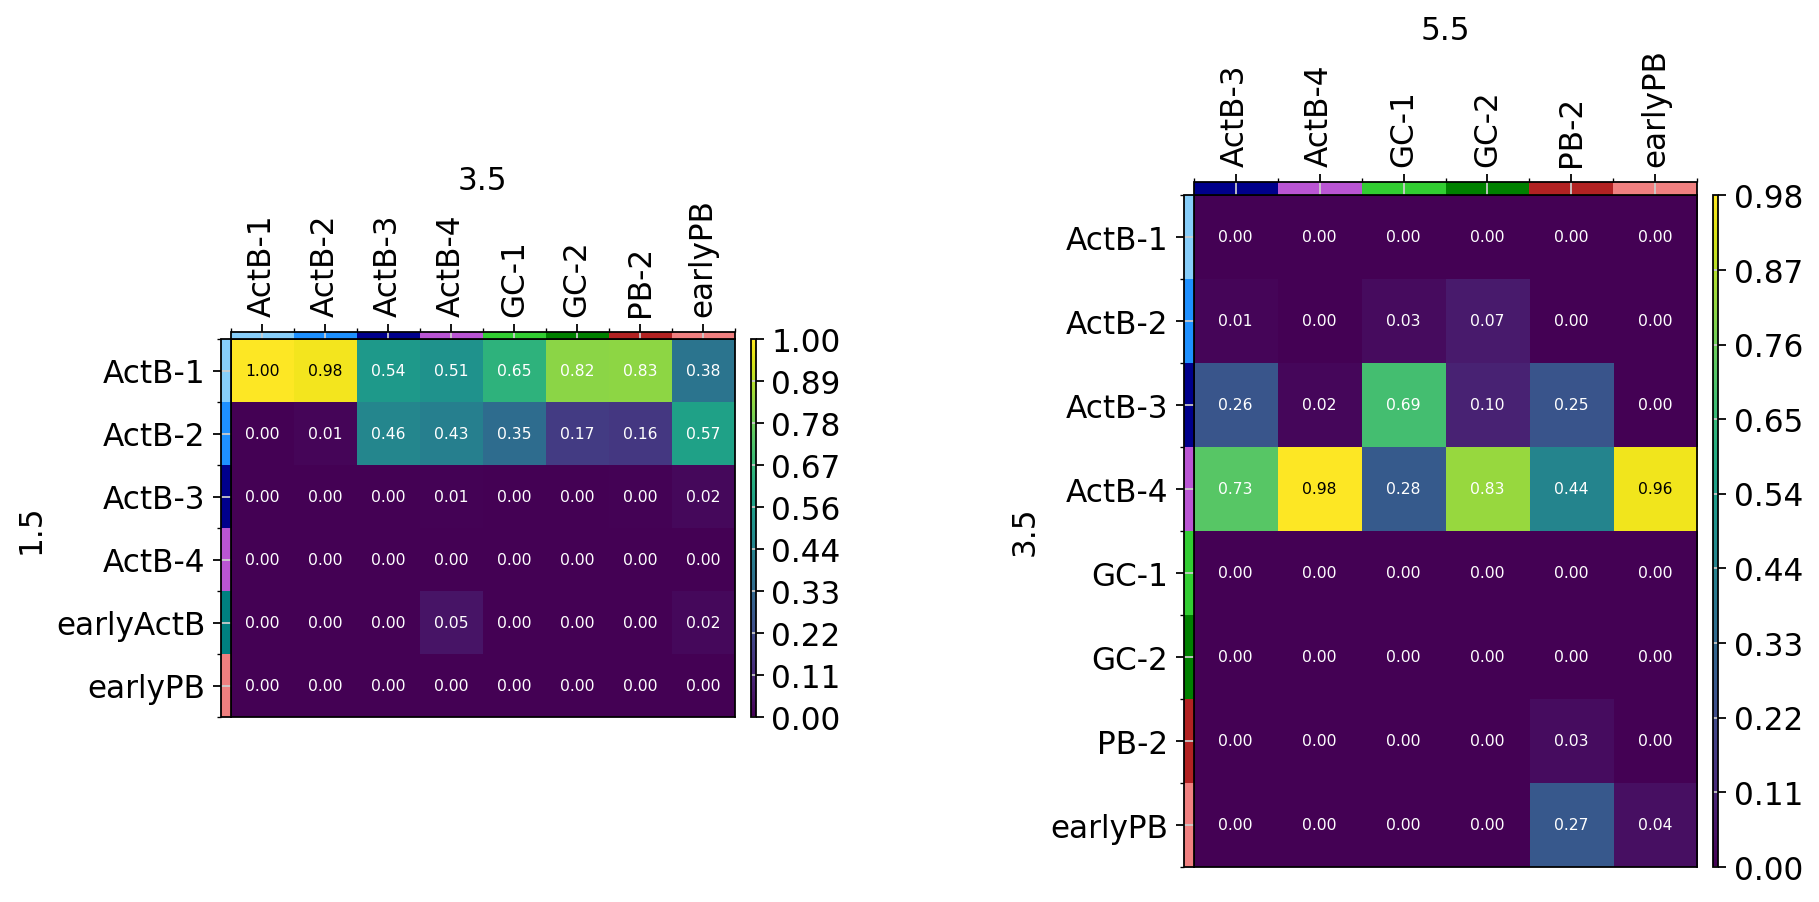

In [30]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_3.5_5.5_large",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5_large",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5_large",
)


fig.subplots_adjust(wspace=0.8)

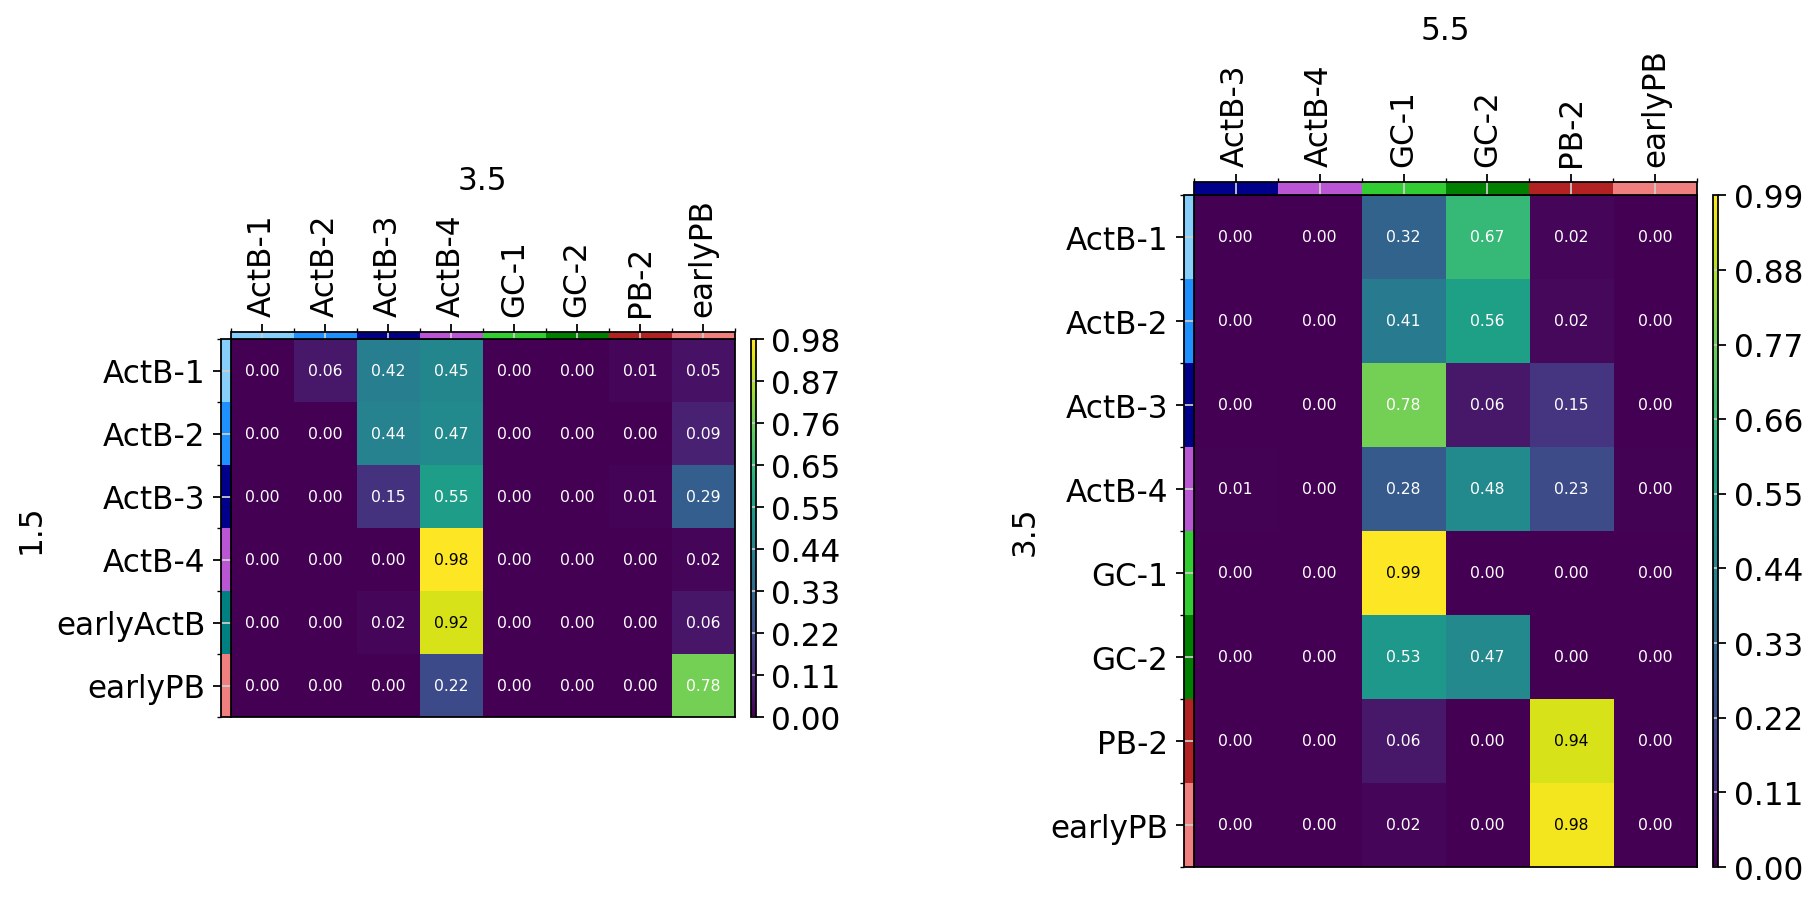

In [31]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_1.5_3.5",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_3.5_5.5",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5",
)


fig.subplots_adjust(wspace=0.8)

### visualizing ancestors and descendants

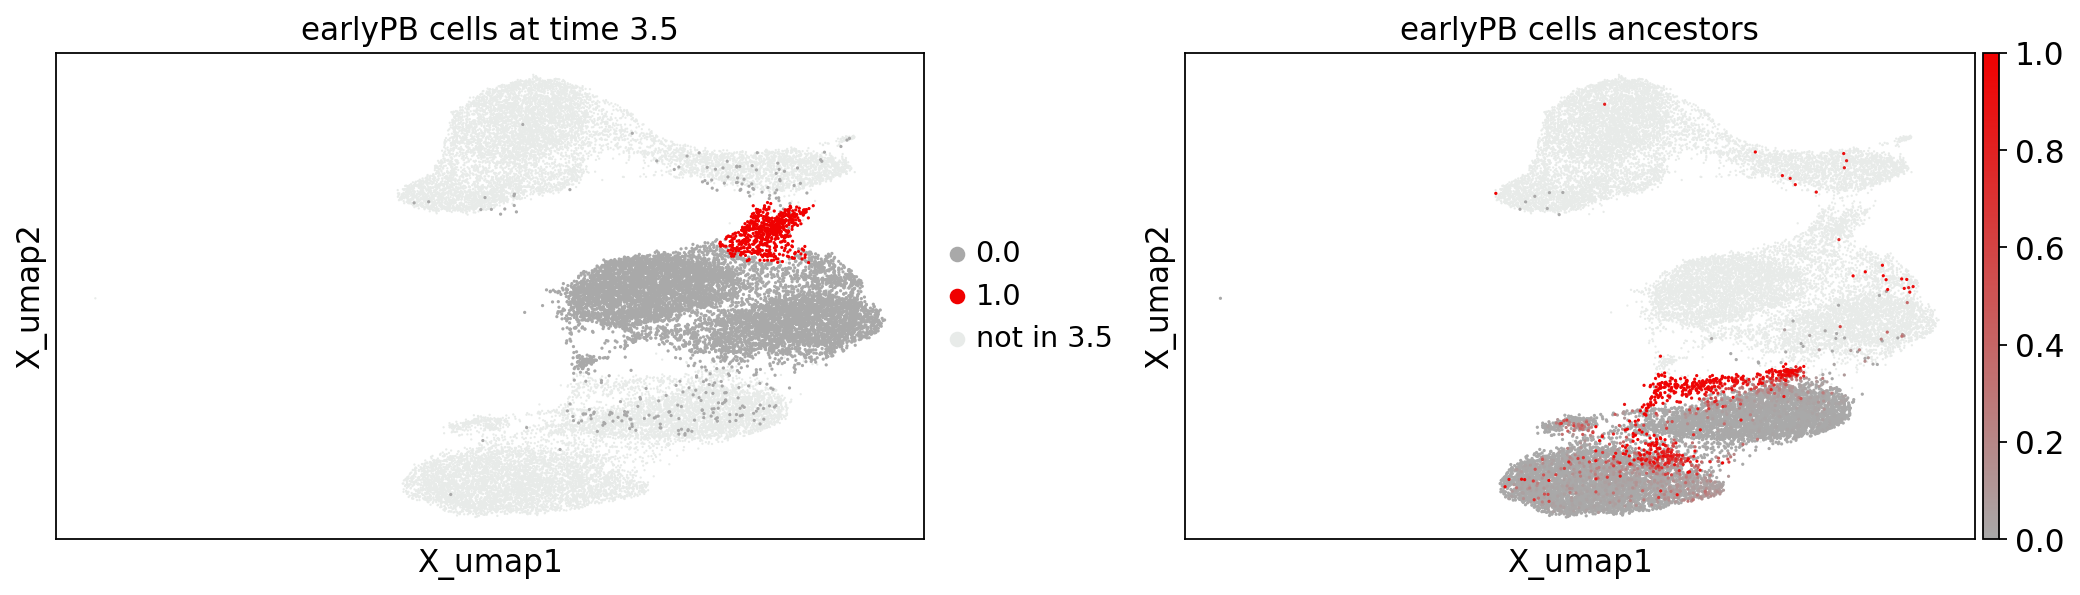

In [21]:
tp0.pull(source=1.5, target=3.5, data="sub_cell_type", subset="earlyPB")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[0],
    title=["earlyPB cells at time 3.5"],
)

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[1],
    title=["earlyPB cells ancestors"],
)

fig.subplots_adjust(wspace=0.3)

In [20]:
tp0.sankey(
    source=3.5,
    target=5.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

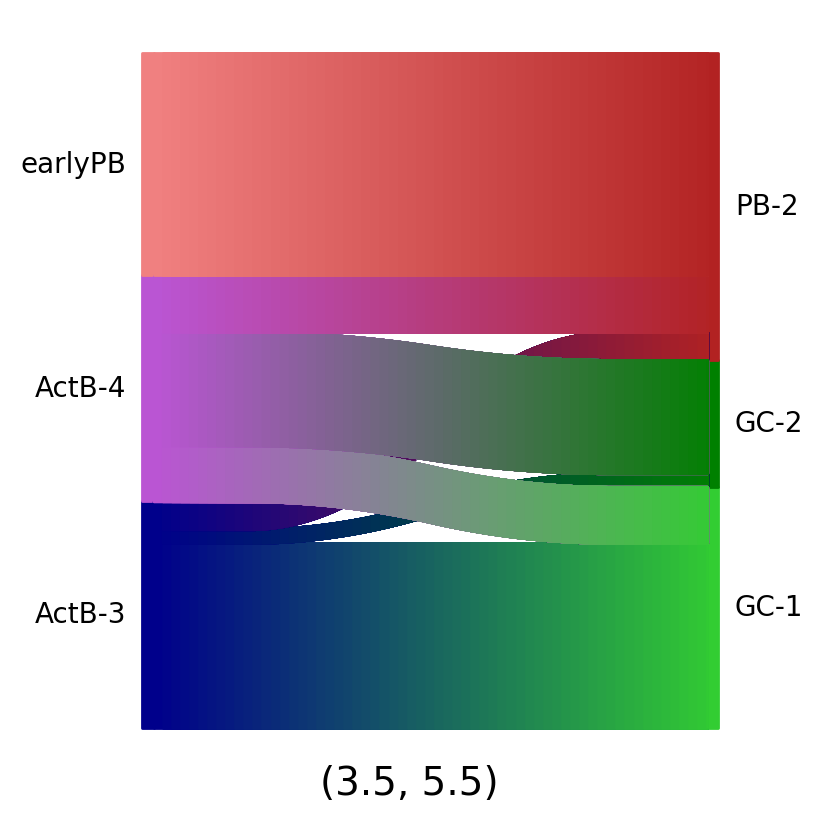

In [21]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

In [24]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

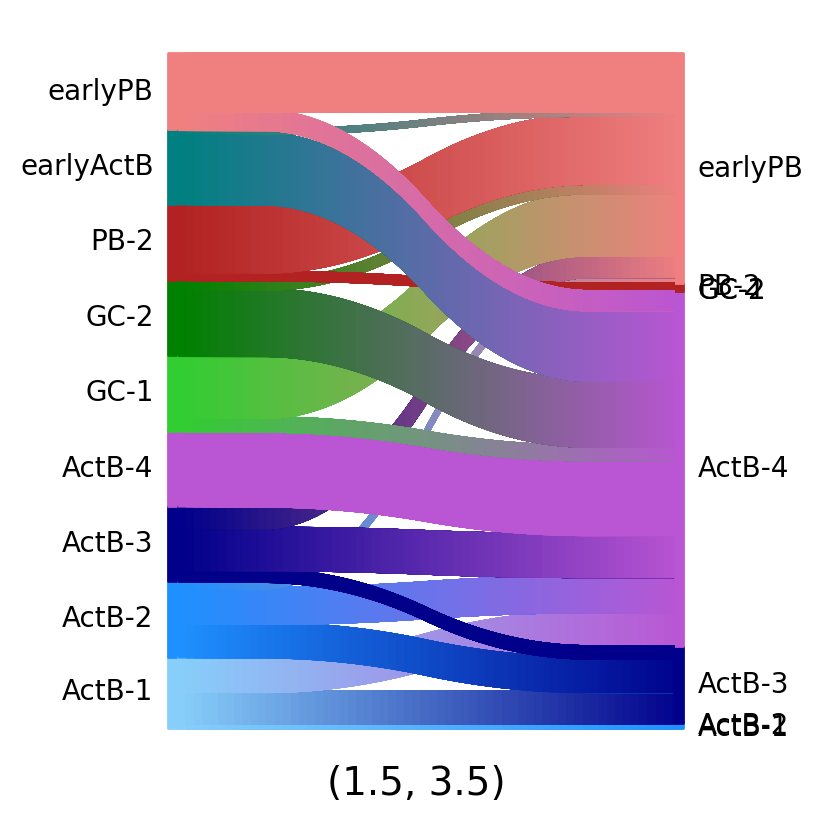

In [25]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

### Identifying driver genes and transcription factors

In [23]:
X_orig = tp0.adata.X.copy()

# 1) Put raw counts into X
tp0.adata.X = tp0.adata.layers["counts"].copy()

# 2) Remove stale flag so scanpy won't warn
tp0.adata.uns.pop("log1p", None)

# 3) Normalize + log1p (now valid because X is counts)
sc.pp.normalize_total(tp0.adata, target_sum=1e4)
sc.pp.log1p(tp0.adata)


In [24]:
def drivers_tf_for_subset(
    tp0,
    subset,
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type", 
    features="human",           
    obs_key_prefix=None,        
    normalize_pull=False,        
    corr_annotation=None,      
):

    prefix = obs_key_prefix
    key_early = f"{prefix}_pull_early"
    key_late  = f"{prefix}_pull_late"
    key_sum   = f"{prefix}_pull"

    tp0.pull(
        t_early[0], t_early[1],
        data=data_key,
        subset=subset[0],
        key_added=key_early,
        normalize=normalize_pull,
    )
    tp0.pull(
        t_late[0], t_late[1],
        data=data_key,
        subset=subset[1],
        key_added=key_late,
        normalize=normalize_pull,
    )

    tp0.adata.obs[key_sum] = tp0.adata.obs[key_early] + tp0.adata.obs[key_late]

    drivers = tp0.compute_feature_correlation(
        obs_key=key_sum,
        features=features,
        annotation=corr_annotation,
    )
    return drivers


In [25]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-3", "earlyPB"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
AHR,0.345564,6.319878e-267,6.414676e-265,0.327621,0.363258
BATF,0.325513,9.193207e-235,6.220737e-233,0.307303,0.343485
NFKB1,0.307079,2.108331e-207,1.069978e-205,0.288638,0.325292
TCF12,0.222924,7.100121e-107,2.402207e-105,0.203609,0.242067
IRF4,0.203904,3.081823e-89,8.937288e-88,0.184431,0.223218
BATF3,0.196889,3.572563e-83,9.065378e-82,0.177361,0.216262
ZBTB7A,0.193998,9.632010e-81,2.056072e-79,0.174449,0.213395
MYC,0.193972,1.012844e-80,2.056072e-79,0.174422,0.213369
SPIB,0.189496,4.910225e-77,9.061597e-76,0.169913,0.208929
ESR1,0.182806,1.056964e-71,1.788030e-70,0.163175,0.202292


In [32]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "earlyPB"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
IKZF2,0.520303,0.000000e+00,0.000000e+00,0.505389,0.534906
STAT4,0.283746,1.191645e-175,1.209519e-173,0.265034,0.302245
ZBTB20,0.242631,4.822140e-127,1.957789e-125,0.223494,0.261582
BCL6,0.230732,1.246774e-114,3.163688e-113,0.211485,0.249800
NR3C2,0.182041,4.177379e-71,6.057200e-70,0.162404,0.201532
NR4A3,0.147301,7.906058e-47,8.024649e-46,0.127446,0.167037
ADARB1,0.132548,3.789035e-38,3.344235e-37,0.112615,0.152373
MXI1,0.129075,3.045511e-36,2.472955e-35,0.109126,0.148920
PAX5,0.128077,1.050647e-35,7.899312e-35,0.108123,0.147928
RUNX1,0.122807,6.171677e-33,4.474466e-32,0.102828,0.142686


In [ ]:
res = drivers_tf_for_subset(
    tp0,
    subset=("earlyPB", "PB-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


In [27]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-3", "GC-1"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
AHR,0.369123,4.262520e-308,8.652915e-306,0.351514,0.386470
NFKB1,0.355734,3.078745e-284,3.124926e-282,0.337932,0.373282
BATF,0.319779,4.970906e-226,3.363647e-224,0.301495,0.337827
SPIB,0.241122,1.984036e-125,6.712656e-124,0.221971,0.260088
MYC,0.226662,1.502783e-110,4.158920e-109,0.207378,0.245769
TCF12,0.226624,1.638983e-110,4.158920e-109,0.207340,0.245731
IRF4,0.203376,8.978041e-89,2.025047e-87,0.183899,0.222694
BATF3,0.202784,2.973723e-88,6.036657e-87,0.183301,0.222106
ZBTB7A,0.188086,6.789356e-76,1.252945e-74,0.168493,0.207531
PBX3,0.183914,1.430298e-72,2.419588e-71,0.164291,0.203391


In [ ]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "GC-1"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


In [ ]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-3", "GC-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


In [28]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "GC-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
IKZF2,0.488146,0.000000e+00,0.000000e+00,0.472580,0.503408
ZBTB20,0.259376,9.546728e-146,3.229976e-144,0.240403,0.278150
STAT4,0.244908,1.681780e-129,4.267516e-128,0.225793,0.263835
BCL6,0.215671,6.106025e-100,9.534793e-99,0.196293,0.234880
NR3C2,0.187232,3.305893e-75,4.473975e-74,0.167632,0.206683
PAX5,0.161043,8.831318e-56,8.963788e-55,0.141269,0.180689
RUNX1,0.152834,2.480853e-50,2.289151e-49,0.133011,0.172535
MXI1,0.128518,6.085913e-36,4.260139e-35,0.108566,0.148366
NR4A3,0.121721,2.217580e-32,1.452157e-31,0.101737,0.141607
ZNF831,0.118673,7.561432e-31,4.796783e-30,0.098676,0.138574


In [29]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-3", "PB-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
PRDM1,0.297015,2.539790e-193,2.577887e-191,0.278454,0.315354
IRF4,0.264446,1.056299e-151,7.147621e-150,0.245526,0.283165
BATF,0.249539,1.397369e-134,7.091650e-133,0.230468,0.268418
XBP1,0.238235,2.252773e-122,9.146259e-121,0.219057,0.257230
RUNX2,0.237538,1.213017e-121,4.104039e-120,0.218354,0.256540
AHR,0.237167,2.967690e-121,8.606300e-120,0.217979,0.256172
ESR1,0.219269,2.391697e-103,6.068931e-102,0.199921,0.238445
TCF12,0.196266,1.201768e-82,2.217808e-81,0.176734,0.215644
NFKB1,0.175381,5.008010e-66,8.471884e-65,0.155700,0.194924
RELB,0.161038,8.910249e-56,1.391370e-54,0.141264,0.180683


In [33]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "PB-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
IKZF2,0.307001,2.721790e-207,5.525233e-205,0.288560,0.325216
ZBTB20,0.208712,1.571576e-93,6.380597e-92,0.189278,0.227984
STAT4,0.174898,1.149950e-65,3.509518e-64,0.155213,0.194444
BCL6,0.131141,2.270950e-37,3.073353e-36,0.111202,0.150975
NR3C2,0.120830,6.278318e-32,7.080547e-31,0.100843,0.140721
ZNF248,0.109336,2.121347e-26,1.794306e-25,0.089299,0.129284
H1FX,0.108806,3.697916e-26,3.002708e-25,0.088767,0.128757
TFEC,0.104523,2.983465e-24,2.163012e-23,0.084468,0.124494
PHF21A,0.103607,7.457002e-24,4.883134e-23,0.083548,0.123582
NR4A3,0.085631,9.270294e-17,5.376770e-16,0.065510,0.105682


In [30]:
res = drivers_tf_for_subset(
    tp0,
    subset=("GC-2", "GC-1"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
NFKB1,0.332740,4.643631e-246,9.426572e-244,0.314624,0.350613
AHR,0.314005,1.930168e-217,1.959120e-215,0.295649,0.332129
SPIB,0.248377,2.693851e-133,1.822839e-131,0.229295,0.267268
BATF,0.240141,2.190958e-124,1.111911e-122,0.220981,0.259116
MYC,0.213402,7.979284e-98,3.239589e-96,0.194006,0.232632
ZEB2,0.190598,6.197352e-78,1.797232e-76,0.171023,0.210022
TCF12,0.180945,2.953329e-70,7.494073e-69,0.161302,0.200446
PBX3,0.171476,3.834239e-63,7.783506e-62,0.151768,0.191047
BATF3,0.162478,9.174103e-57,1.693039e-55,0.142713,0.182114
IRF4,0.154596,1.781590e-51,3.013857e-50,0.134783,0.174285


In [31]:
res = drivers_tf_for_subset(
    tp0,
    subset=("earlyPB", "PB-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)
res.head(10)


,None_pull_corr,None_pull_pval,None_pull_qval,None_pull_ci_low,None_pull_ci_high
PRDM1,0.528815,0.000000e+00,0.000000e+00,0.514082,0.543237
XBP1,0.256922,6.498716e-143,4.397464e-141,0.237924,0.275723
RUNX2,0.243927,1.941259e-128,9.851888e-127,0.224802,0.262864
POU2AF1,0.243692,3.484077e-128,1.414535e-126,0.224565,0.262631
BHLHE41,0.235169,3.557803e-119,1.203723e-117,0.215963,0.254194
MDM2,0.227189,4.496450e-111,1.303970e-109,0.207910,0.246291
MBNL2,0.203364,9.205902e-89,2.076442e-87,0.183887,0.222682
ATF5,0.194205,6.471196e-81,1.194230e-79,0.174657,0.213600
DUSP22,0.149221,4.984049e-48,5.325063e-47,0.129377,0.168945
IRF4,0.146467,2.594775e-46,2.633697e-45,0.126608,0.166208
